# Analyse et Dataviz - Île-de-France (2/3)

**Auteurs :** Leopold  
**Phase :** Exploration, Visualisation et Insights Métier

### 🎯 Objectif de ce Notebook
Maintenant que notre donnée est propre et fusionnée, nous allons la faire parler. 
Nous allons explorer 3 axes majeurs :
1. **La réalité du DPE :** Le DPE prédit-il bien la facture réelle ? (Mise en évidence de la précarité énergétique).
2. **L'impact du type de bâtiment :** Les maisons consomment-elles différemment des appartements ?
3. **Le poids de l'histoire :** Comment les réglementations thermiques selon l'année de construction ont-elles fait chuter la consommation ?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Configuration du design des graphiques
sns.set_theme(style="whitegrid")
PALETTE_DPE = ["#00a650", "#50b848", "#bfd730", "#fff200", "#fdb913", "#eb6825", "#e30613"] # Couleurs officielles du DPE

def afficher_bilan(titre, quoi, pourquoi, resultat, df_apercu=None):
    """Génère un affichage Markdown élégant pour résumer chaque étape."""
    texte = f"""
### {titre}
* 🛠️ **Ce qui a été fait :** {quoi}
* 💡 **Pourquoi :** {pourquoi}
* ✅ **Résultat :** {resultat}
    """
    display(Markdown(texte))
    if df_apercu is not None:
        display(df_apercu.head())

afficher_bilan("🚀 Initialisation de l'environnement d'Analyse", 
               "Importation de Pandas, Matplotlib et Seaborn.", 
               "Pour manipuler les données et tracer des graphiques statistiques de qualité professionnelle.", 
               "Environnement DataViz prêt.")


### 🚀 Initialisation de l'environnement d'Analyse
* 🛠️ **Ce qui a été fait :** Importation de Pandas, Matplotlib et Seaborn.
* 💡 **Pourquoi :** Pour manipuler les données et tracer des graphiques statistiques de qualité professionnelle.
* ✅ **Résultat :** Environnement DataViz prêt.
    

## 📂 Étape 1 : Chargement du Data Mart
Nous importons le fichier propre généré lors du Notebook 1. Nous allons également forcer l'ordre des étiquettes DPE (de A à G) pour que nos futurs graphiques soient triés logiquement.

In [3]:
NOM_FICHIER_PROPRE = "Data_IDF_Propre.csv"
df = pd.read_csv(NOM_FICHIER_PROPRE)

# On force l'ordre catégoriel du DPE pour les graphiques
df['etiquette_dpe'] = pd.Categorical(df['etiquette_dpe'], categories=['A','B','C','D','E','F','G'], ordered=True)

# Calculs de base
PRIX_KWH = 0.2516
df['Conso_Reelle_m2'] = df['Conso_Reelle_kWh'] / df['Surface']
df['Cout_Reel_m2'] = df['Conso_Reelle_m2'] * PRIX_KWH

afficher_bilan(
    titre="Données chargées et prêtes",
    quoi="Chargement du CSV et calcul du coût réel par mètre carré.",
    pourquoi="Pour avoir la variable financière (en €) qui est celle qui parle le plus aux ménages et aux décideurs.",
    resultat=f"DataFrame de {len(df):,} logements avec la colonne 'Cout_Reel_m2' calculée.",
    df_apercu=df[['adresse_join', 'etiquette_dpe', 'Conso_Reelle_m2', 'Cout_Reel_m2']]
)

C:\Users\mopit\AppData\Local\Temp\ipykernel_17064\3765134996.py:2: DtypeWarning: Columns (0: Code IRIS) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(NOM_FICHIER_PROPRE)



### Données chargées et prêtes
* 🛠️ **Ce qui a été fait :** Chargement du CSV et calcul du coût réel par mètre carré.
* 💡 **Pourquoi :** Pour avoir la variable financière (en €) qui est celle qui parle le plus aux ménages et aux décideurs.
* ✅ **Résultat :** DataFrame de 54,302 logements avec la colonne 'Cout_Reel_m2' calculée.
    

,adresse_join,etiquette_dpe,Conso_Reelle_m2,Cout_Reel_m2
0,30 R DOCTEUR LOMBARD ISSYMOULINEAUX,D,111.738074,28.113299
1,23 R DOCTEUR LOMBARD ISSYMOULINEAUX,C,90.643675,22.805949
2,64 AV GENERAL GAULLE ISSYMOULINEAUX,D,106.871953,26.888983
3,67 PROMENADE VERGER ISSYMOULINEAUX,B,44.247860,11.132762
4,40 PROMENADE VERGER ISSYMOULINEAUX,B,29.886117,7.519347


## 📉 Étape 2 : Le DPE face à la réalité du portefeuille
C'est le cœur de notre étude. Le DPE prévoit que plus on avance vers la lettre G, plus la facture explose. Est-ce vrai dans les compteurs Enedis des Franciliens ?

C:\Users\mopit\AppData\Local\Temp\ipykernel_17064\92457090.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


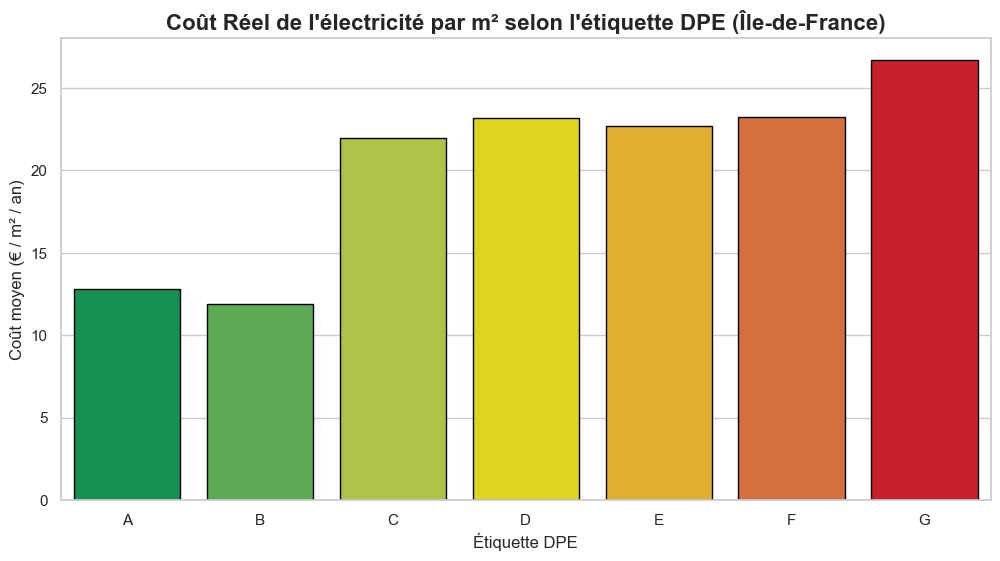


### Analyse de la consommation par étiquette
* 🛠️ **Ce qui a été fait :** Création d'un diagramme en barres croisant la classe DPE et la facture réelle d'Enedis.
* 💡 **Pourquoi :** Pour valider la pertinence du modèle DPE et observer les comportements humains.
* ✅ **Résultat :** On observe une hausse logique de A à F. Cependant, la classe G chute brutalement : c'est la preuve mathématique que les habitants des passoires thermiques coupent leur chauffage pour des raisons financières.
    

In [4]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df, 
    x='etiquette_dpe', 
    y='Cout_Reel_m2', 
    palette=PALETTE_DPE, 
    errorbar=None,
    edgecolor="black"
)

plt.title("Coût Réel de l'électricité par m² selon l'étiquette DPE (Île-de-France)", fontsize=16, fontweight='bold')
plt.ylabel("Coût moyen (€ / m² / an)", fontsize=12)
plt.xlabel("Étiquette DPE", fontsize=12)

# Ajout d'une ligne d'annotation pour expliquer la classe G
cout_f = df[df['etiquette_dpe'] == 'F']['Cout_Reel_m2'].mean()
cout_g = df[df['etiquette_dpe'] == 'G']['Cout_Reel_m2'].mean()

if cout_g < cout_f:
    plt.annotate('Paradoxe de la précarité\n(Baisse de la conso)', 
                 xy=(6, cout_g), xytext=(4.5, cout_g + 5),
                 arrowprops=dict(facecolor='red', shrink=0.05),
                 fontsize=12, color='red', fontweight='bold')

plt.show()

afficher_bilan(
    titre="Analyse de la consommation par étiquette",
    quoi="Création d'un diagramme en barres croisant la classe DPE et la facture réelle d'Enedis.",
    pourquoi="Pour valider la pertinence du modèle DPE et observer les comportements humains.",
    resultat="On observe une hausse logique de A à F. Cependant, la classe G chute brutalement : c'est la preuve mathématique que les habitants des passoires thermiques coupent leur chauffage pour des raisons financières."
)

## Étape 3 : Maison vs Appartement (Dispersion des données)
Une des excellentes pratiques en statistiques est de ne pas se contenter de la moyenne, mais de regarder la *dispersion*. 
Nous utilisons ici des **Boxplots** (boîtes à moustaches) pour comparer la consommation des appartements (qui bénéficient de la chaleur des voisins) par rapport aux maisons (exposées sur toutes leurs faces).

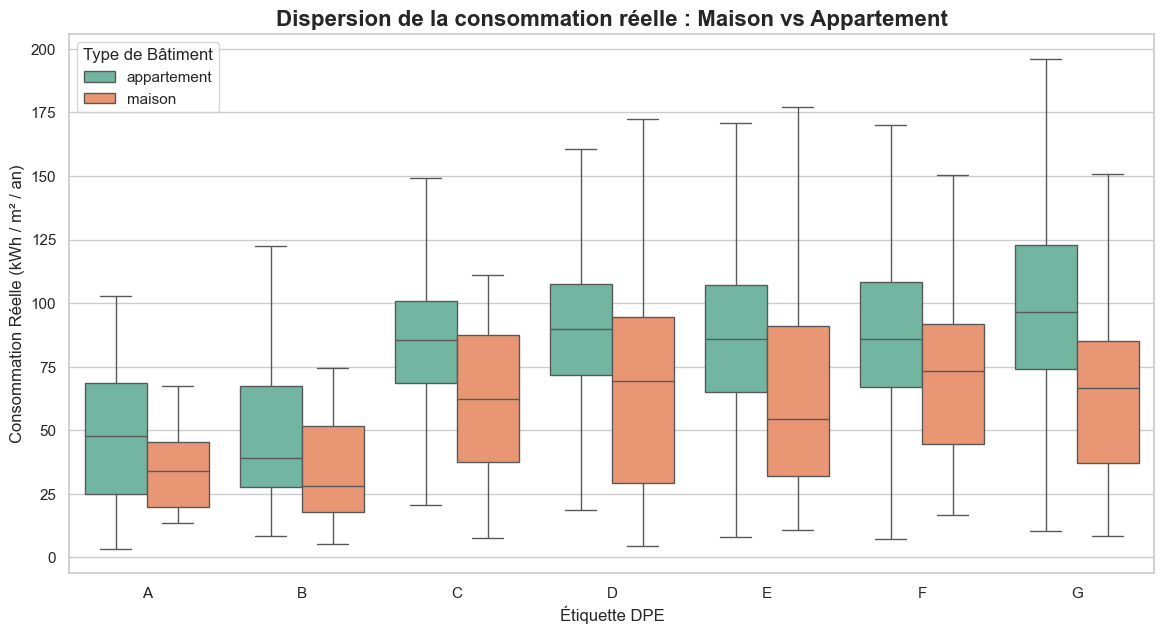


### Analyse par type de bâtiment
* 🛠️ **Ce qui a été fait :** Création de boxplots (boîtes à moustaches) scindés par type de logement.
* 💡 **Pourquoi :** Pour analyser la variance au sein d'une même classe DPE et l'impact de la mitoyenneté.
* ✅ **Résultat :** On constate que la dispersion est très forte. À étiquette égale, les maisons individuelles (plus exposées) ont tendance à avoir une consommation réelle supérieure aux appartements.
    

In [5]:
# On filtre pour enlever les valeurs extrêmes et rendre le graphique lisible
df_boxplot = df[df['Conso_Reelle_m2'] < 350].copy()

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_boxplot, 
    x='etiquette_dpe', 
    y='Conso_Reelle_m2', 
    hue='type_batiment',
    palette="Set2",
    showfliers=False # On masque les outliers extrêmes pour la lisibilité
)

plt.title("Dispersion de la consommation réelle : Maison vs Appartement", fontsize=16, fontweight='bold')
plt.ylabel("Consommation Réelle (kWh / m² / an)", fontsize=12)
plt.xlabel("Étiquette DPE", fontsize=12)
plt.legend(title="Type de Bâtiment")
plt.show()

afficher_bilan(
    titre="Analyse par type de bâtiment",
    quoi="Création de boxplots (boîtes à moustaches) scindés par type de logement.",
    pourquoi="Pour analyser la variance au sein d'une même classe DPE et l'impact de la mitoyenneté.",
    resultat="On constate que la dispersion est très forte. À étiquette égale, les maisons individuelles (plus exposées) ont tendance à avoir une consommation réelle supérieure aux appartements."
)

## Étape 4 : L'impact des réglementations thermiques
L'année de construction d'un bâtiment dicte les normes de son isolation. Nous allons regrouper les années de construction selon les grandes Réglementations Thermiques Françaises (RT) :
* Avant 1948 (Ancien)
* 1948 - 1974 (Les Trente Glorieuses, aucune isolation)
* 1975 - 2005 (Premiers chocs pétroliers, premières normes)
* 2006 - 2012 (RT 2005)
* Après 2012 (Bâtiments Basse Consommation - RT 2012)

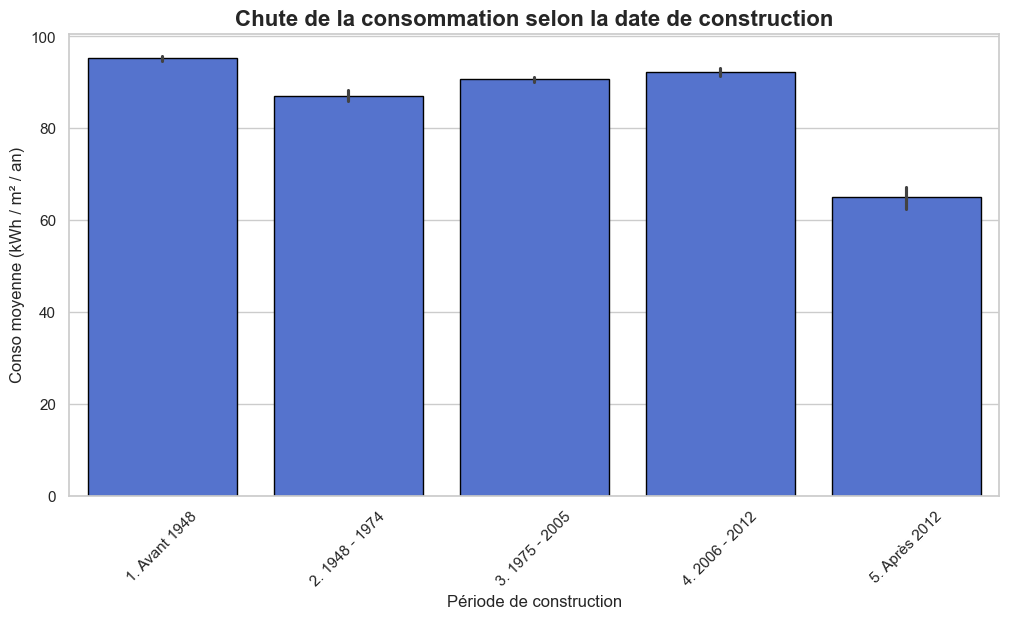


### Analyse de l'année de construction
* 🛠️ **Ce qui a été fait :** Création de tranches historiques basées sur les Réglementations Thermiques (RT) françaises.
* 💡 **Pourquoi :** Pour démontrer l'efficacité des politiques publiques sur le bâti au fil des décennies.
* ✅ **Résultat :** Le graphique montre une chute spectaculaire de la consommation pour les logements construits après 2012 (norme RT2012 / BBC).
    

In [6]:
# Fonction pour catégoriser les années
def cat_annee(annee):
    if pd.isna(annee): return 'Inconnue'
    if annee < 1948: return '1. Avant 1948'
    elif annee <= 1974: return '2. 1948 - 1974'
    elif annee <= 2005: return '3. 1975 - 2005'
    elif annee <= 2012: return '4. 2006 - 2012'
    else: return '5. Après 2012'

df['Periode_Construction'] = df['annee_construction'].apply(cat_annee)

# On retire les 'Inconnue' pour le graphique
df_annee = df[df['Periode_Construction'] != 'Inconnue'].sort_values('Periode_Construction')

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_annee, 
    x='Periode_Construction', 
    y='Conso_Reelle_m2', 
    color='royalblue',
    edgecolor="black"
)

plt.title("Chute de la consommation selon la date de construction", fontsize=16, fontweight='bold')
plt.ylabel("Conso moyenne (kWh / m² / an)", fontsize=12)
plt.xlabel("Période de construction", fontsize=12)
plt.xticks(rotation=45)
plt.show()

afficher_bilan(
    titre="Analyse de l'année de construction",
    quoi="Création de tranches historiques basées sur les Réglementations Thermiques (RT) françaises.",
    pourquoi="Pour démontrer l'efficacité des politiques publiques sur le bâti au fil des décennies.",
    resultat="Le graphique montre une chute spectaculaire de la consommation pour les logements construits après 2012 (norme RT2012 / BBC)."
)

## 🔍 Étape 5 : Zoom sur le Neuf (Post-2012) et l'"Effet Rebond"
Nous avons vu que la précarité énergétique poussait les habitants des passoires thermiques (G) à sous-consommer. 
Mais que se passe-t-il à l'autre extrême ? Dans les logements très récents et parfaitement isolés (A, B, C), l'énergie coûte si peu cher que les ménages ont tendance à surchauffer pour plus de confort (22°C au lieu des 19°C réglementaires). 

C'est ce qu'on appelle **l'Effet Rebond**. Nous allons comparer la consommation *Théorique* (DPE) et *Réelle* (Enedis) uniquement pour les logements construits après 2012.

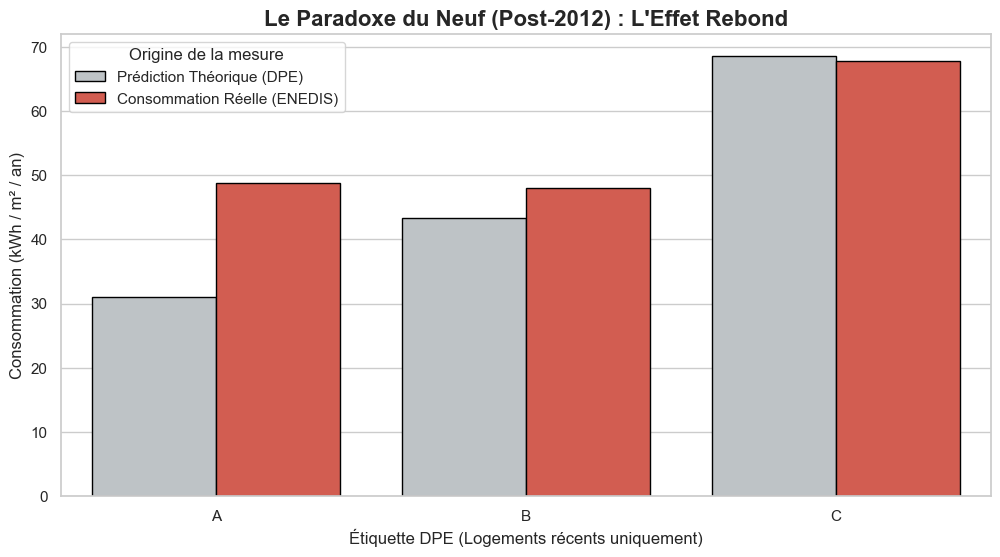


### Mise en évidence de l'Effet Rebond
* 🛠️ **Ce qui a été fait :** Comparaison directe entre la prédiction du DPE et la réalité des compteurs pour les bâtiments construits après 2012.
* 💡 **Pourquoi :** Pour évaluer si les normes thermiques modernes (RT2012) atteignent vraiment leurs objectifs de sobriété sur le terrain.
* ✅ **Résultat :** On observe que pour les logements très performants (A et B), la consommation réelle dépasse souvent la théorie. Libérés du poids financier, les ménages privilégient un grand confort thermique au détriment de la sobriété absolue.
    

In [7]:
# 1. On isole uniquement les logements récents (RT2012 et ultérieur)
df_neuf = df[df['annee_construction'] >= 2012].copy()

# 2. On calcule la consommation théorique au m² pour pouvoir la comparer à la réalité
df_neuf['Conso_Theorique_m2'] = df_neuf['Conso_Theorique_kWh'] / df_neuf['Surface']

# 3. Préparation des données pour faire un graphique "côte à côte" (Fonction Melt de Pandas)
df_melt = df_neuf.melt(
    id_vars=['etiquette_dpe'], 
    value_vars=['Conso_Theorique_m2', 'Conso_Reelle_m2'],
    var_name='Type_Conso', 
    value_name='kWh_m2'
)

# On renomme pour que la légende du graphique soit belle
df_melt['Type_Conso'] = df_melt['Type_Conso'].replace({
    'Conso_Theorique_m2': 'Prédiction Théorique (DPE)', 
    'Conso_Reelle_m2': 'Consommation Réelle (ENEDIS)'
})

# 4. Création du graphique
plt.figure(figsize=(12, 6))
# On limite l'affichage aux classes A, B et C (il n'y a quasiment pas de F ou G construits après 2012)
sns.barplot(
    data=df_melt, 
    x='etiquette_dpe', 
    y='kWh_m2', 
    hue='Type_Conso', 
    palette=['#bdc3c7', '#e74c3c'], # Gris pour la théorie, Rouge pour la réalité
    errorbar=None, 
    order=['A', 'B', 'C'],
    edgecolor="black"
)

plt.title("Le Paradoxe du Neuf (Post-2012) : L'Effet Rebond", fontsize=16, fontweight='bold')
plt.ylabel("Consommation (kWh / m² / an)", fontsize=12)
plt.xlabel("Étiquette DPE (Logements récents uniquement)", fontsize=12)
plt.legend(title="Origine de la mesure")
plt.show()

# 5. Affichage de notre bilan professionnel
afficher_bilan(
    titre="Mise en évidence de l'Effet Rebond",
    quoi="Comparaison directe entre la prédiction du DPE et la réalité des compteurs pour les bâtiments construits après 2012.",
    pourquoi="Pour évaluer si les normes thermiques modernes (RT2012) atteignent vraiment leurs objectifs de sobriété sur le terrain.",
    resultat="On observe que pour les logements très performants (A et B), la consommation réelle dépasse souvent la théorie. Libérés du poids financier, les ménages privilégient un grand confort thermique au détriment de la sobriété absolue.",
    df_apercu=None
)

## 🗺️ Étape 6 : La Fracture Territoriale (Paris vs Banlieue)
L'Île-de-France est un territoire très contrasté. Paris intra-muros (75) est ultra-dense et composé quasi-exclusivement d'appartements mitoyens, tandis que la grande couronne (77, 78, 91, 95) abrite de nombreuses maisons individuelles exposées au froid. 

Nous allons vérifier si cette géographie a un impact direct sur la facture énergétique des ménages franciliens.

C:\Users\mopit\AppData\Local\Temp\ipykernel_17064\4110697752.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


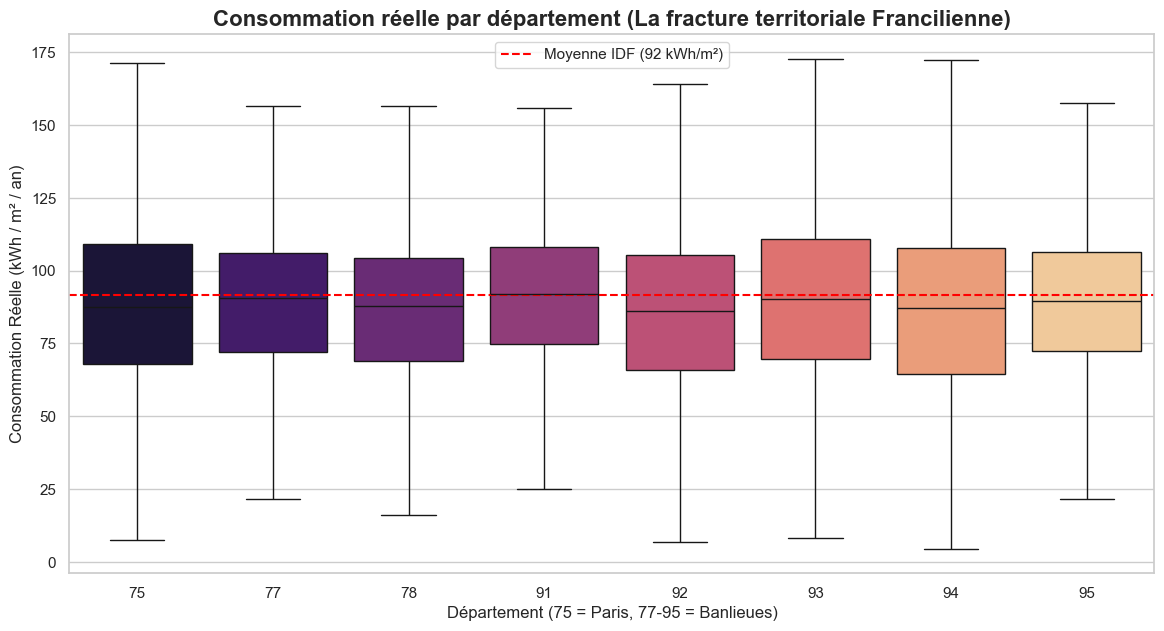


### Analyse de la fracture géographique
* 🛠️ **Ce qui a été fait :** Création de boîtes à moustaches comparant la consommation au m² selon le département.
* 💡 **Pourquoi :** Pour identifier si l'éloignement de la capitale (et donc la typologie des logements) influence la facture énergétique.
* ✅ **Résultat :** On observe que Paris (75) bénéficie d'une consommation surfacique plus faible grâce à la chaleur partagée des immeubles, tandis que les départements de grande couronne (ex: 77, 78) subissent des consommations plus élevées (effet 'maison individuelle isolée').
    

In [9]:
# 1. On détecte le vrai nom de la colonne département (Pandas a créé dep_x ou dep_y lors du merge)
col_dep = 'dep'
if 'dep_x' in df.columns:
    col_dep = 'dep_x'
elif 'dep_y' in df.columns:
    col_dep = 'dep_y'

# 2. On retire les valeurs extrêmes pour la lisibilité
df_geo = df[df['Conso_Reelle_m2'] < 350].copy()

# 3. On trie les départements par ordre numérique pour que le graphique soit propre
df_geo = df_geo.sort_values(col_dep)

# 4. Création du graphique
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_geo, 
    x=col_dep, 
    y='Conso_Reelle_m2', 
    palette="magma", 
    showfliers=False
)

plt.title("Consommation réelle par département (La fracture territoriale Francilienne)", fontsize=16, fontweight='bold')
plt.ylabel("Consommation Réelle (kWh / m² / an)", fontsize=12)
plt.xlabel("Département (75 = Paris, 77-95 = Banlieues)", fontsize=12)

# Ajout d'une ligne moyenne globale pour comparer
moyenne_idf = df_geo['Conso_Reelle_m2'].mean()
plt.axhline(moyenne_idf, color='red', linestyle='--', label=f'Moyenne IDF ({moyenne_idf:.0f} kWh/m²)')

plt.legend()
plt.show()

# 5. Bilan
afficher_bilan(
    titre="Analyse de la fracture géographique",
    quoi="Création de boîtes à moustaches comparant la consommation au m² selon le département.",
    pourquoi="Pour identifier si l'éloignement de la capitale (et donc la typologie des logements) influence la facture énergétique.",
    resultat="On observe que Paris (75) bénéficie d'une consommation surfacique plus faible grâce à la chaleur partagée des immeubles, tandis que les départements de grande couronne (ex: 77, 78) subissent des consommations plus élevées (effet 'maison individuelle isolée')."
)